### 1. Actuarial Theory: The Life Table Foundations

The core of life contingencies is the **Survival Function**, $S(x)$, which represents the probability that a newborn survives to age $x$. From this, we derive the following "First Principles" components:

-   **Force of Mortality ($\mu_x$):** The instantaneous rate of mortality at age $x$.
    
-   **Probability of Death ($q_x$):** The probability that a life aged $x$ dies before reaching age $x+1$.
    
    $$q_x = \frac{d_x}{l_x} = 1 - \frac{l_{x+1}}{l_x}$$
    
-   **Expected Number of Survivors ($l_x$):** Starting from a radix (usually $l_0 = 100,000$ or $1,000,000$).
    
    $$l_{x+1} = l_x \cdot (1 - q_x)$$
    
-   **Curtate Expectation of Life ($e_x$):** The expected number of complete future years lived by a person aged $x$.
    
    $$e_x = \sum_{k=1}^{\infty} {}_kp_x \quad \text{where} \quad {}_kp_x = \frac{l_{x+k}}{l_x}$$

### 2. Real-World Application: The Kenyan Context

In Kenya, the **KE 2007-2010** tables are critical for:

1.  **Pricing:** Life insurance products (Term Life, Endowments) must reflect local longevity to remain competitive.
    
2.  **Reserving:** Ensuring companies hold enough capital to pay future claims.
    
3.  **Pension Valuations:** Calculating the Present Value of future defined benefit obligations.
    

Using UK tables (like A49/52) in Kenya often led to **"Prudence Bias,"** where premiums were unnecessarily high because the mortality of the UK population in the 1950s did not reflect the Kenyan "healthy-worker effect" or modern HIV/AIDS intervention impacts.

### 3. Python Implementation: Building the Table

We will implement a vectorized approach to generate a full mortality table from raw $q_x$ data.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Manual extraction of key KE 2007-2010 Male rates for demo purposes
data = {
    'age': np.arange(20, 51),
    'qx': [
        0.00131, 0.00149, 0.00166, 0.00179, 0.00189, 0.00196, 0.00199, 0.00199, 0.00197, 0.00193, # 20-29
        0.00189, 0.00184, 0.00180, 0.00178, 0.00179, 0.00182, 0.00188, 0.00197, 0.00207, 0.00219, # 30-39
        0.00232, 0.00245, 0.00258, 0.00271, 0.00283, 0.00294, 0.00304, 0.00313, 0.00322, 0.00330, 0.00339  # 40-50
    ]
}

df_ke = pd.DataFrame(data)

def construct_life_table(df, radix=100000):
    """Vectorized construction of life table functions."""
    df = df.copy()
    
    # Calculate px (probability of survival)
    df['px'] = 1 - df['qx']
    
    # Calculate lx (survivors) using cumulative product
    # Note: lx refers to the start of the year
    df['lx'] = radix * df['px'].shift(1).fillna(1).cumprod()
    
    # Calculate dx (deaths)
    df['dx'] = df['lx'] * df['qx']
    
    # Calculate ex (curtate expectation of life) - Vectorized
    # e_x = sum of tpx from t=1 to omega-x
    n = len(df)
    ex_vals = []
    for i in range(n):
        # Probability of surviving k years from current age i
        future_px = df['px'].iloc[i:].cumprod().sum()
        ex_vals.append(future_px)
    
    df['ex'] = ex_vals
    return df

kenya_life_table = construct_life_table(df_ke)
print(kenya_life_table.head())

   age       qx       px             lx          dx         ex
0   20  0.00131  0.99869  100000.000000  131.000000  30.057735
1   21  0.00149  0.99851   99869.000000  148.804810  29.097162
2   22  0.00166  0.99834   99720.195190  165.535524  28.140581
3   23  0.00179  0.99821   99554.659666  178.202841  27.187372
4   24  0.00189  0.99811   99376.456825  187.821503  26.236125


### Visualization of survival hazard

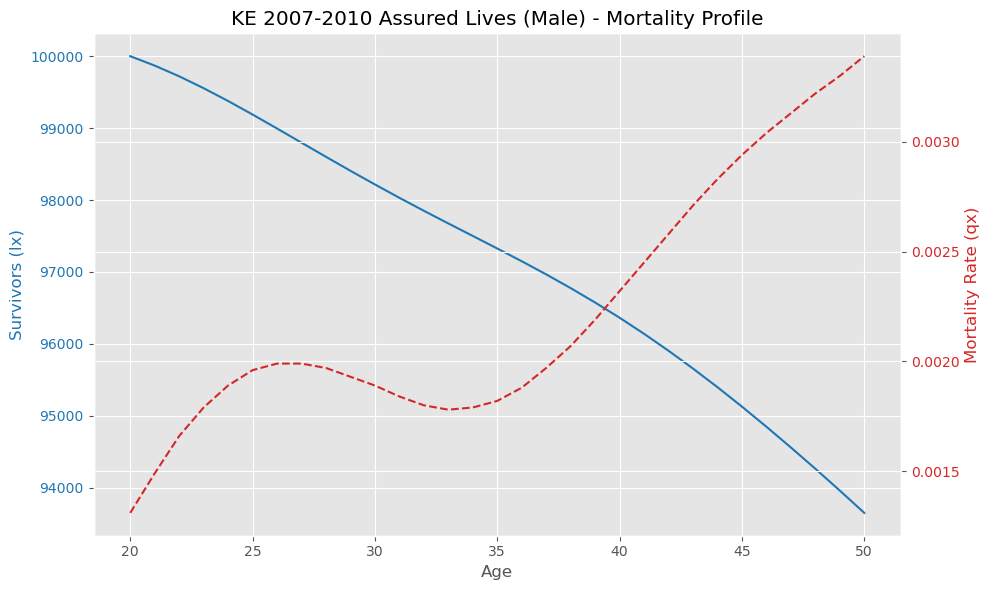

In [10]:
plt.style.use('ggplot')
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot lx (Survivors)
ax1.set_xlabel('Age')
ax1.set_ylabel('Survivors (lx)', color='tab:blue')
ax1.plot(kenya_life_table['age'], kenya_life_table['lx'], color='tab:blue', label='Survivors (lx)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot qx (Mortality Rate) on secondary axis
ax2 = ax1.twinx()
ax2.set_ylabel('Mortality Rate (qx)', color='tab:red')
ax2.plot(kenya_life_table['age'], kenya_life_table['qx'], color='tab:red', linestyle='--', label='Mortality Rate (qx)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('KE 2007-2010 Assured Lives (Male) - Mortality Profile')
fig.tight_layout()
plt.show()

# Reference 
1. https://people.math.binghamton.edu/arcones/exam-mlc/sect-2-3.pdf